<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns


In [12]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [15]:
#verificando informações da base
penguins.info()
penguins.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


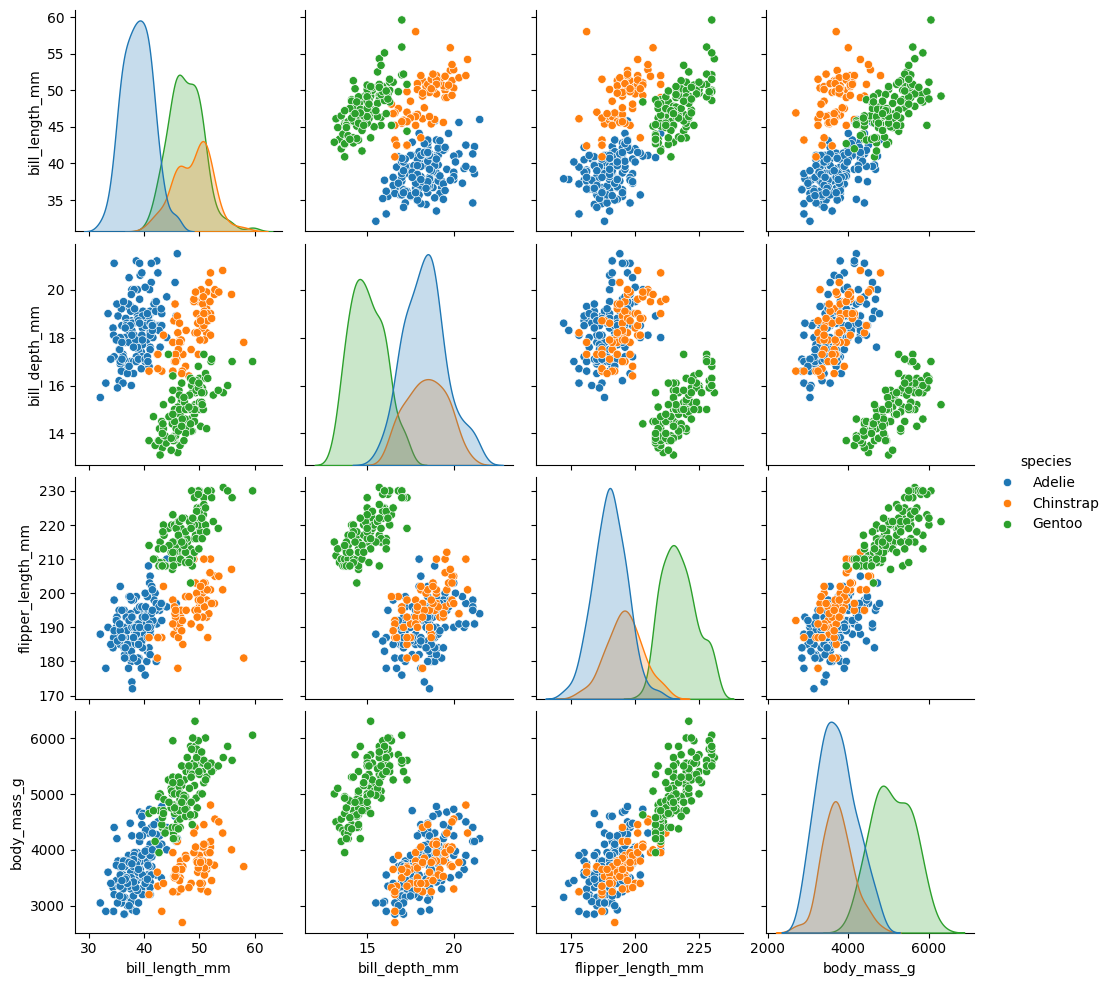

In [19]:
# 1. Importar bibliotecas
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Carregar a base de dados
penguins = sns.load_dataset("penguins")

# 3. Remover valores nulos
penguins = penguins.dropna()

# 4. Criar o pairplot
sns.pairplot(penguins, hue='species')

# 5. Mostrar o gráfico
plt.show()

Ao visualizar o pairplot, é possível identificar a formação de agrupamentos naturais entre os dados. Os pontos apresentam separações visíveis principalmente nas variáveis relacionadas ao tamanho do bico, tamanho da nadadeira e massa corporal. Visualmente é possível observar aproximadamente três agrupamentos, o que está de acordo com as três espécies presentes no dataset: Adelie, Chinstrap e Gentoo.

In [20]:
# Selecionando apenas variáveis númericas:
X = penguins[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']]

In [23]:
#Padronizando os dados
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

#Transformando novamente em dataFrame.
X_padronizado = pd.DataFrame(X_padronizado, columns=X.columns)

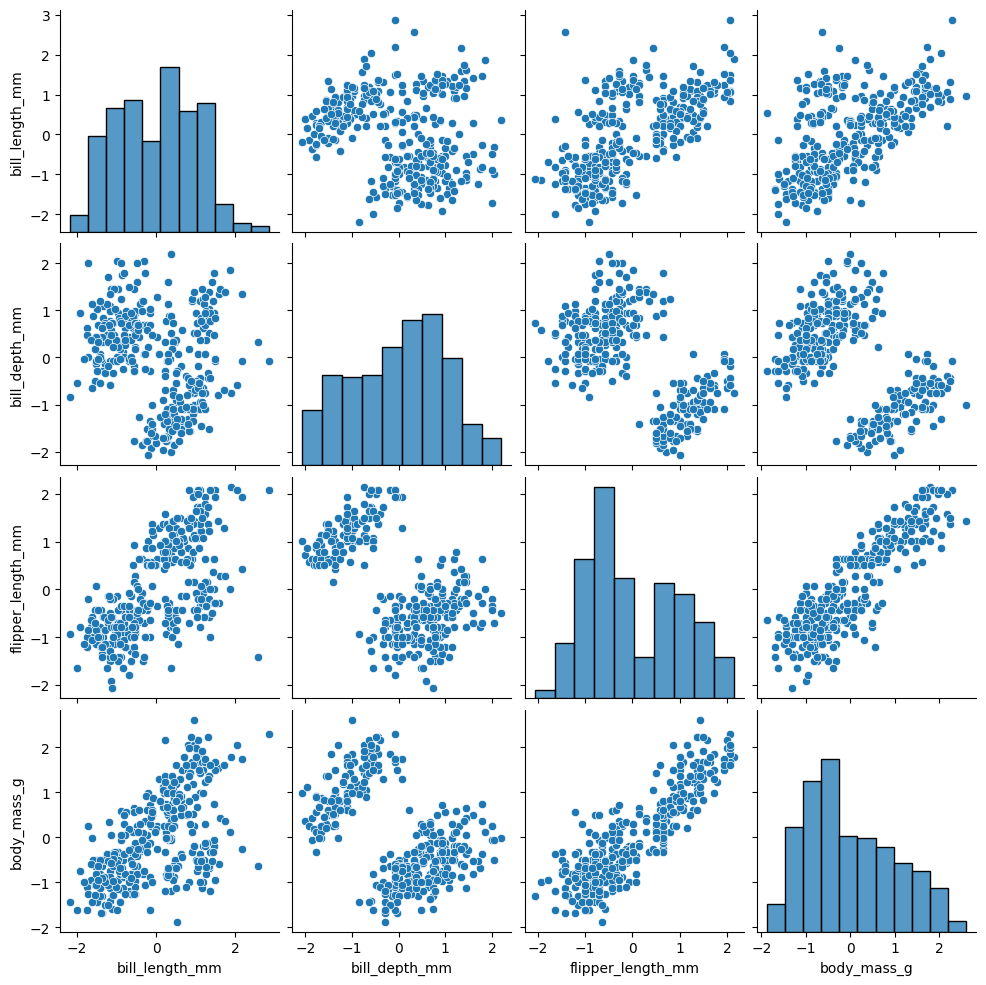

In [25]:
#Visualizando os dados padronizados
sns.pairplot(X_padronizado)
plt.show()

In [26]:
#Copiando a base ja padronizada
base = X_padronizado.copy()

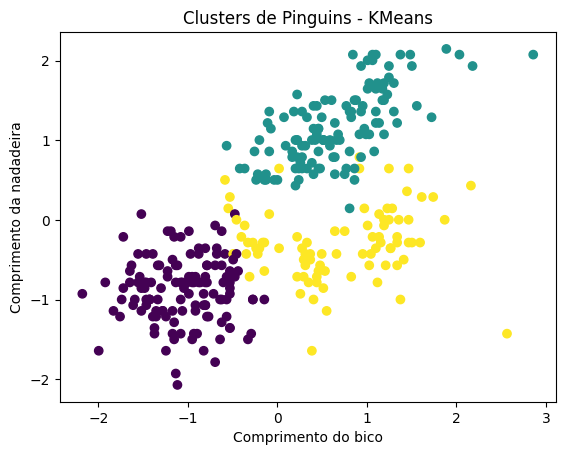

In [28]:
#Escolhendo número de clusters = 3 mesmo quantidade de espécie que temos na base
kmeans = KMeans(n_clusters=3, random_state=42)

base['cluster'] = kmeans.fit_predict(base)

plt.scatter(base['bill_length_mm'], base['flipper_length_mm'], c=base['cluster'])

plt.xlabel('Comprimento do bico')
plt.ylabel('Comprimento da nadadeira')
plt.title('Clusters de Pinguins - KMeans')

plt.show()

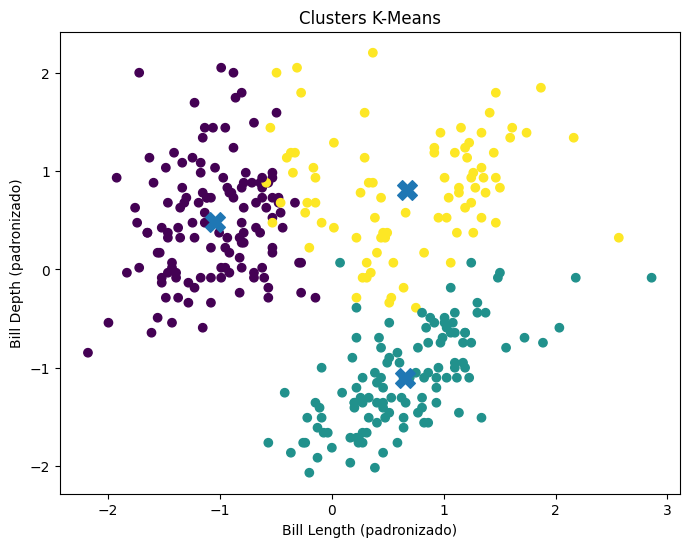

In [29]:

# obter os centroides
centroides = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

# pontos
plt.scatter(base['bill_length_mm'], base['bill_depth_mm'],
            c=base['cluster'])

# centroides
plt.scatter(centroides[:,0], centroides[:,1],
            marker='X', s=200)

plt.xlabel('Bill Length (padronizado)')
plt.ylabel('Bill Depth (padronizado)')
plt.title('Clusters K-Means')

plt.show()

Usando:

x = bill_length_mm

y = bill_depth_mm

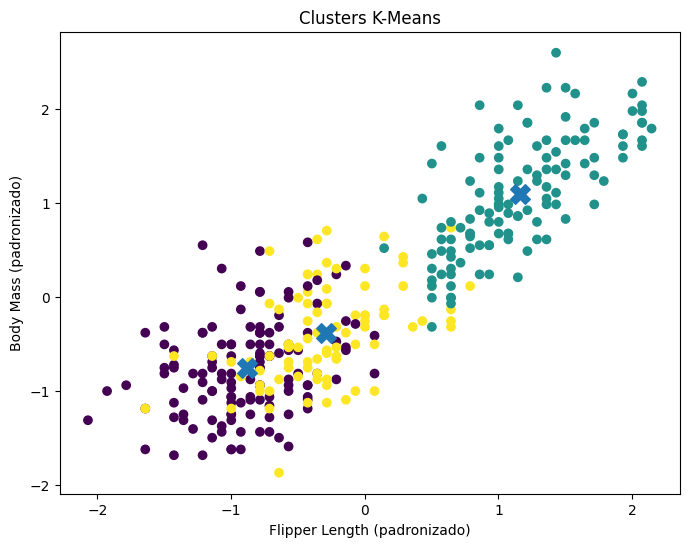

In [30]:
plt.figure(figsize=(8,6))

# pontos
plt.scatter(base['flipper_length_mm'], base['body_mass_g'],
            c=base['cluster'])

# centroides
plt.scatter(centroides[:,2], centroides[:,3],
            marker='X', s=200)

plt.xlabel('Flipper Length (padronizado)')
plt.ylabel('Body Mass (padronizado)')
plt.title('Clusters K-Means')

plt.show()

Agora usando outras variáveis, por exemplo:

x = flipper_length_mm

y = body_mass_g

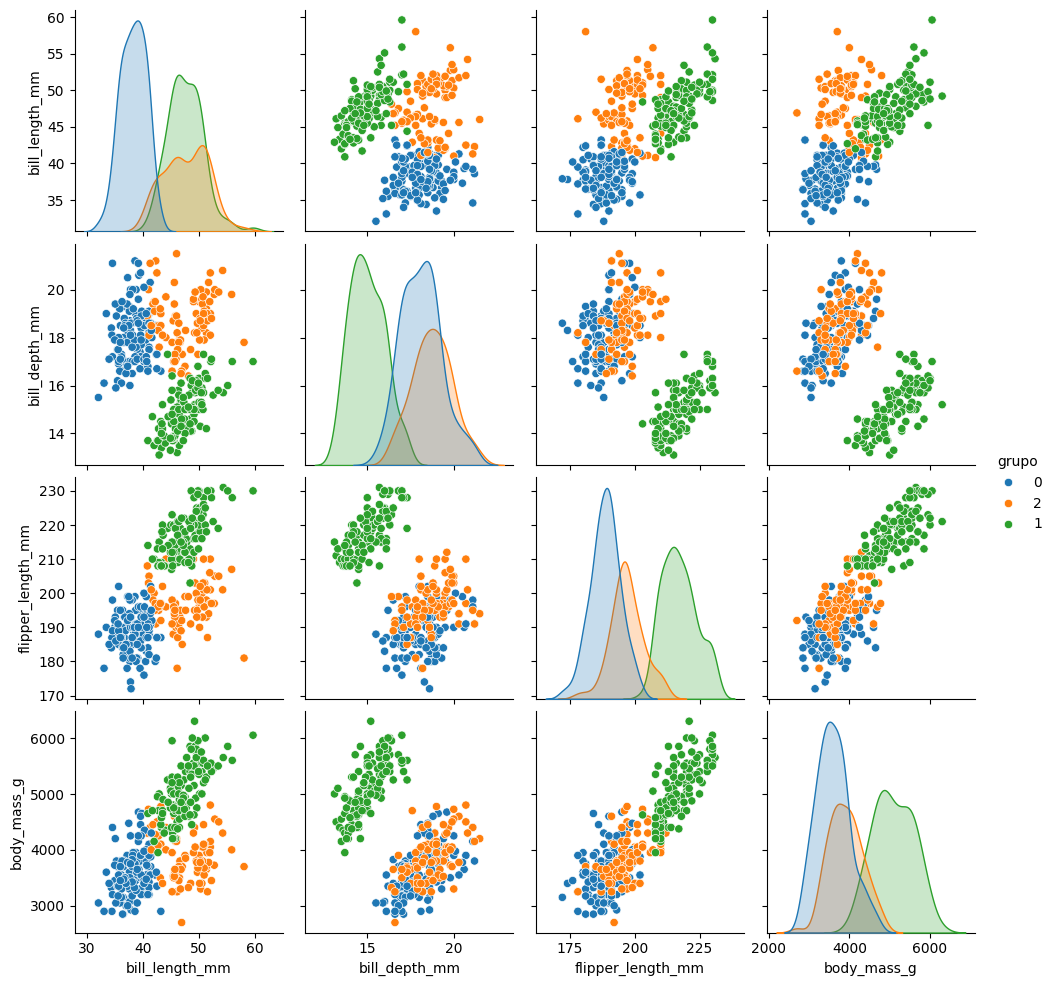

In [31]:
penguins['grupo'] = kmeans.labels_.astype('str')
sns.pairplot(penguins, hue='grupo')


Os agrupamentos parecem satisfatórios, pois é possível observar três grupos relativamente distintos no gráfico. As variáveis que parecem permitir melhor separação entre os clusters são flipper_length_mm e body_mass_g, enquanto bill_length_mm e bill_depth_mm apresentam maior sobreposição entre os grupos.

**3 - Utilidades de Aplicações de algoritmos de Clusterização:**

1- Segmentação de clientes para estratégias de marketing.

2 - Detecção de fraudes em transações financeiras.

3 - Segmentação e análise de imagens em aplicações de visão computacional.